In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from ortools.linear_solver import pywraplp

# Optional: Set plot style for better aesthetics
plt.style.use('seaborn-v0_8-whitegrid')

In [17]:
# 1. Load Data
# (Make sure your working directory is the root folder where /base_data is located)
employees_df = pd.read_csv('base_data/nexus_employees.csv')
tasks_df = pd.read_csv('base_data/nexus_tasks.csv')

# 2. Helper Functions
def parse_skill_string(skill_str):
    if pd.isna(skill_str): return {}
    return {item.split(':')[0]: int(item.split(':')[1]) for item in skill_str.split('|')}

def calculate_skill_rho(emp_level, task_level):
    if emp_level == 0: return 0.2  # Missing skill penalty
    elif emp_level == task_level: return 1.0  # Perfect match
    elif emp_level > task_level: return 1.5  # Over-qualified (faster)
    else: return 0.5  # Under-qualified penalty

# 3. Apply Parsing
employees_df['Specific_Skills_Dict'] = employees_df['Specific_Skills'].apply(parse_skill_string)
tasks_df['Req_Dict'] = tasks_df['Skills_Needed'].apply(parse_skill_string)
tasks_df['Predecessors_List'] = tasks_df['Predecessors'].apply(lambda x: json.loads(x) if pd.notna(x) else [])

print(f"Loaded {len(employees_df)} employees and {len(tasks_df)} tasks.")

Loaded 49 employees and 104 tasks.


In [18]:
# --- PARAMETERS ---
HOURS_PER_DAY = 8
TAU_PENALTY = 20
TIME_WEIGHT = 500
M_CAP = 9999 # Big-M for the logic switch

solver = pywraplp.Solver.CreateSolver('SCIP')

# 1. Determine Valid Pairs and Rhos
valid_pairs = []
rho_dict = {} 
for _, emp in employees_df.iterrows():
    emp_skills = emp.get('Specific_Skills_Dict', {})
    for _, task in tasks_df.iterrows():
        task_reqs = task.get('Req_Dict', {})
        skill_rhos = []
        missing_count = 0
        for skill, req_level in task_reqs.items():
            emp_level = emp_skills.get(skill, 0)
            if emp_level == 0: missing_count += 1
            skill_rhos.append(calculate_skill_rho(emp_level, req_level))
        
        if missing_count < len(task_reqs): # Must have at least one relevant skill
            valid_pairs.append((emp['Employee_ID'], task['Task_ID']))
            rho_dict[(emp['Employee_ID'], task['Task_ID'])] = min(skill_rhos)

# 2. Variables
x = {} # Hours worked
y = {} # Binary switch (Context penalty)
for (i, j) in valid_pairs:
    x[(i, j)] = solver.IntVar(0, solver.infinity(), f'x_{i}_{j}')
    y[(i, j)] = solver.BoolVar(f'y_{i}_{j}')

S = {} # Start Day
F = {} # Finish Day
for j in tasks_df['Task_ID']:
    S[j] = solver.NumVar(0, solver.infinity(), f'Start_{j}')
    F[j] = solver.NumVar(0, solver.infinity(), f'Finish_{j}')

C_max = solver.NumVar(0, solver.infinity(), 'Makespan') 

# 3. Constraints
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()

# A. Big-M Linking & Capacity
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    cap_constraint = solver.Constraint(0, float(cap_dict[i]))
    for j in assigned_tasks:
        # Big-M: x <= M * y
        link_const = solver.Constraint(-solver.infinity(), 0)
        link_const.SetCoefficient(x[(i, j)], 1)
        link_const.SetCoefficient(y[(i, j)], -M_CAP)
        
        # Capacity constraint includes tau penalty
        cap_constraint.SetCoefficient(x[(i, j)], 1)
        cap_constraint.SetCoefficient(y[(i, j)], TAU_PENALTY)

# B. Demand & Time Calculations
for j in tasks_df['Task_ID']:
    capable_emps = [i for (i, t_id) in valid_pairs if t_id == j]
    
    # Demand: Sum of (Hours * Rho) >= Required
    dem_const = solver.Constraint(float(demand_dict[j]), solver.infinity())
    
    # Duration: Finish - Start >= Sum of (Hours) / 8
    dur_const = solver.Constraint(0, solver.infinity())
    dur_const.SetCoefficient(F[j], 1)
    dur_const.SetCoefficient(S[j], -1)
    
    # Makespan tracker
    make_const = solver.Constraint(0, solver.infinity())
    make_const.SetCoefficient(C_max, 1)
    make_const.SetCoefficient(F[j], -1)
    
    for i in capable_emps:
        dem_const.SetCoefficient(x[(i, j)], float(rho_dict[(i, j)]))
        dur_const.SetCoefficient(x[(i, j)], -(1.0 / HOURS_PER_DAY))

# C. Precedence Constraint (Task Ordering!)
for _, task in tasks_df.iterrows():
    j = task['Task_ID']
    for p in task.get('Predecessors_List', []):
        prec_const = solver.Constraint(0, solver.infinity())
        prec_const.SetCoefficient(S[j], 1)
        prec_const.SetCoefficient(F[p], -1)

# 4. Multi-Objective Function (Cost + Time)
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()
for (i, j) in valid_pairs:
    wage = float(cost_dict[i])
    objective.SetCoefficient(x[(i, j)], wage)
    objective.SetCoefficient(y[(i, j)], wage * TAU_PENALTY)

objective.SetCoefficient(C_max, TIME_WEIGHT)
objective.SetMinimization()

print("Solving the TechNova Portfolio...")
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"✅ OPTIMAL SOLUTION FOUND!")
    print(f"Total Objective Value: ${solver.Objective().Value():,.2f}")
    print(f"Total Makespan: {C_max.solution_value():.1f} Days")
else:
    print("❌ SOLVER FAILED (Infeasible or Timeout)")

Solving the TechNova Portfolio...
✅ OPTIMAL SOLUTION FOUND!
Total Objective Value: $1,316,485.00
Total Makespan: 130.5 Days


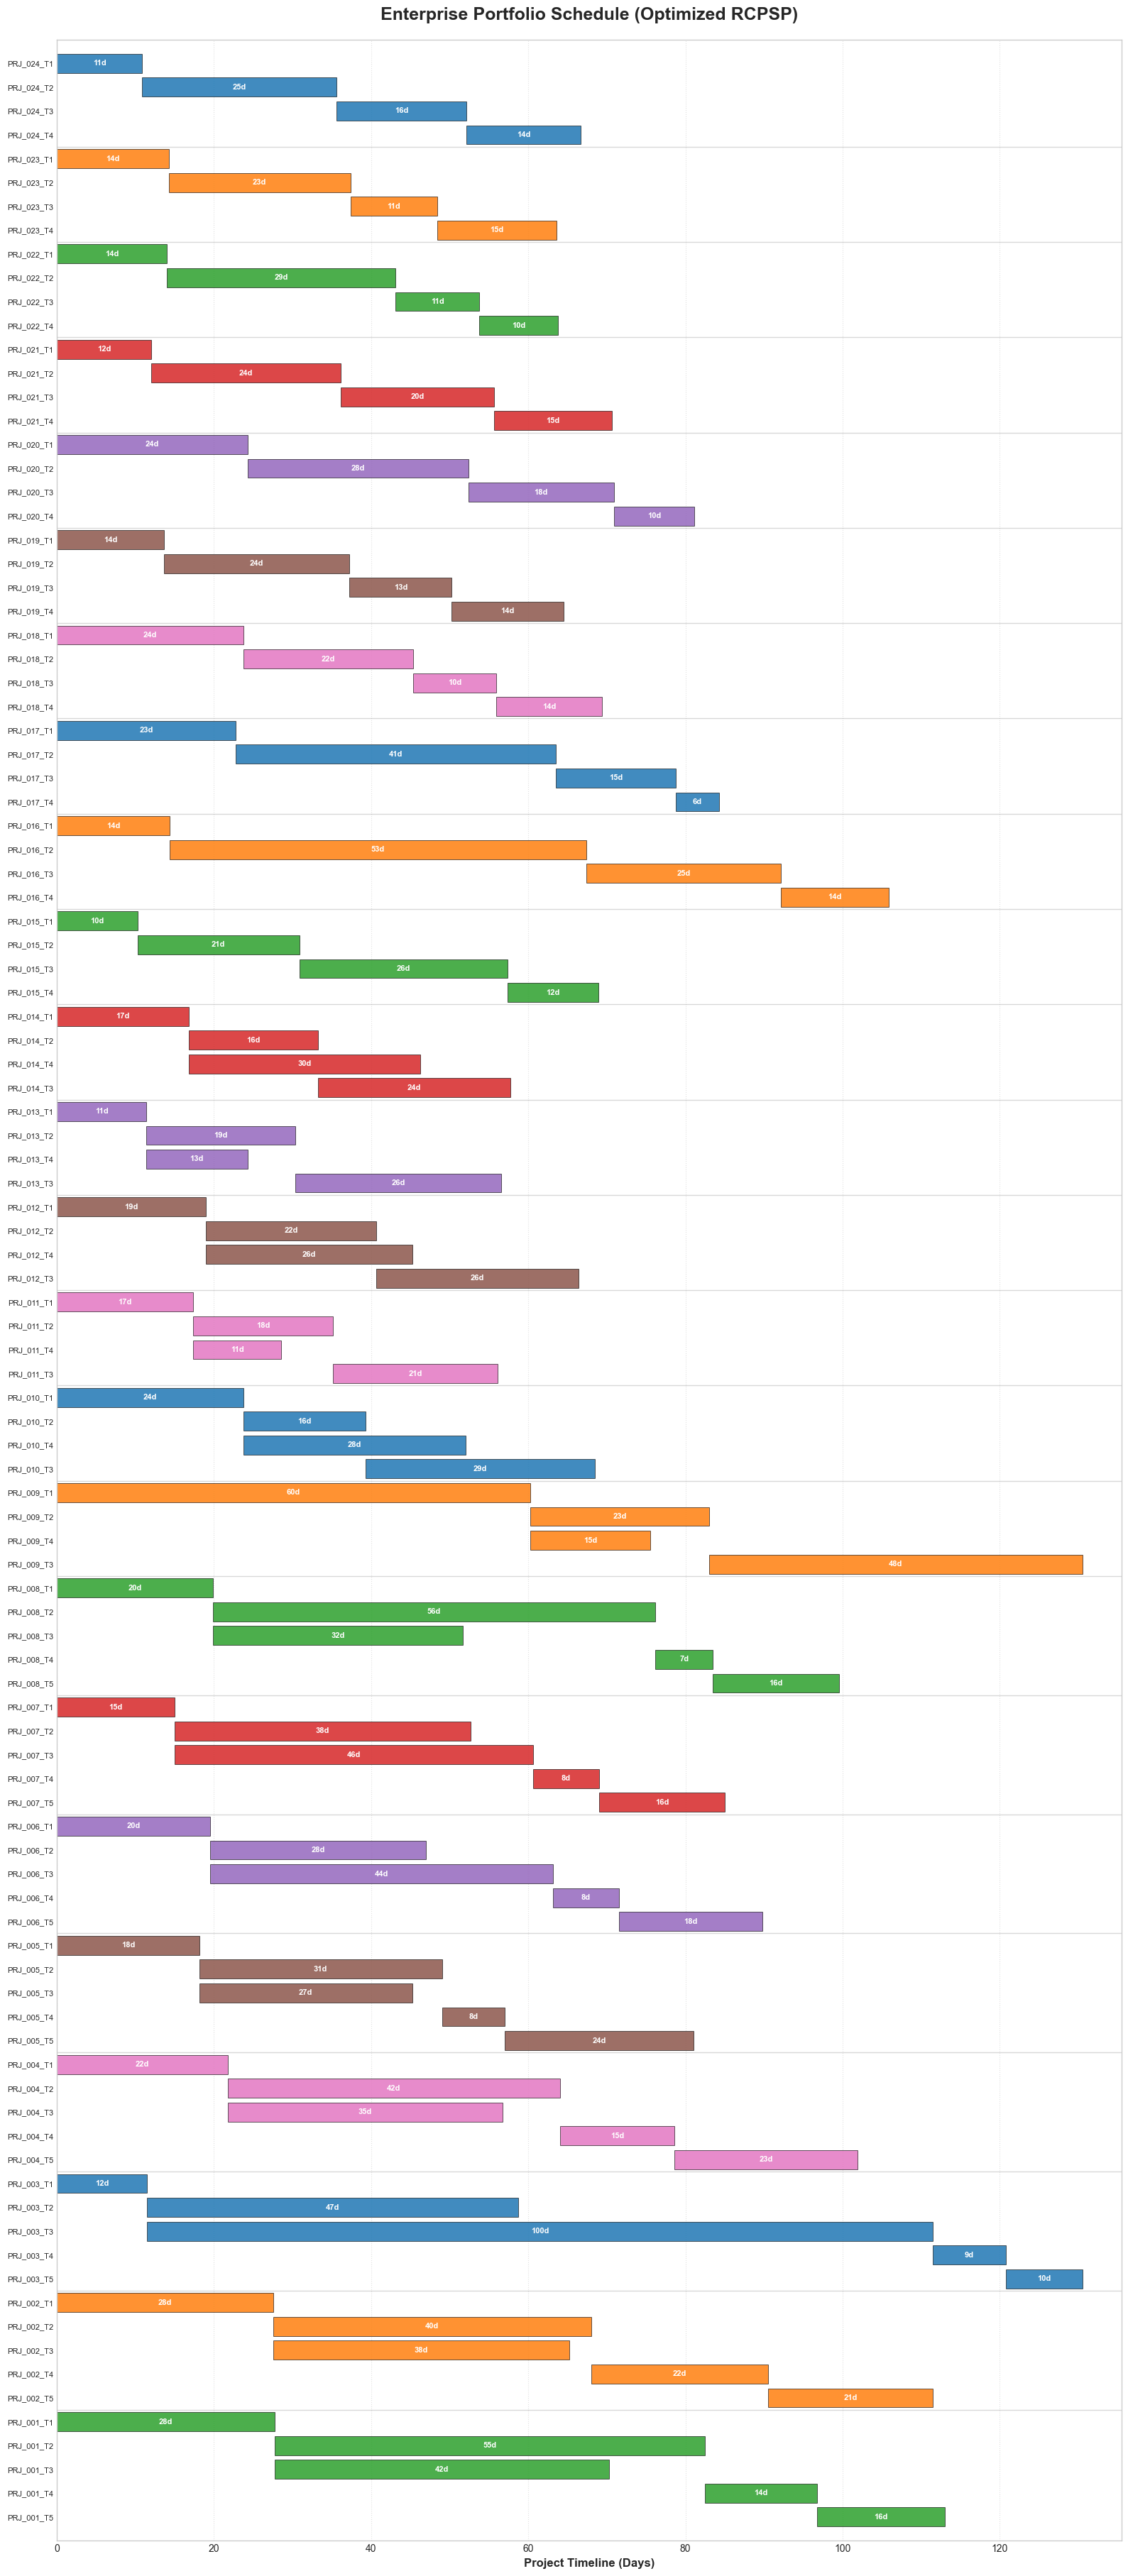

In [20]:
# ==========================================
# CELL 4: DATA EXTRACTION & DYNAMIC GANTT CHART
# ==========================================

# 1. Extract the schedule data from the solver into df_gantt
schedule_data = []
for j in tasks_df['Task_ID']:
    schedule_data.append({
        'Task_ID': j,
        'Project_ID': tasks_df[tasks_df['Task_ID'] == j]['Project_ID'].values[0],
        'Start': S[j].solution_value(),
        'Finish': F[j].solution_value(),
        'Duration': F[j].solution_value() - S[j].solution_value()
    })

# This is the missing dataframe!
df_gantt = pd.DataFrame(schedule_data).sort_values(by=['Project_ID', 'Start'], ascending=[False, True])

# Assign colors to different projects
projects = df_gantt['Project_ID'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'] 
color_map = {proj: colors[i % len(colors)] for i, proj in enumerate(projects)}

# 2. Dynamic Figure Size (Scales with the number of tasks)
row_height = 0.35 
fig_height = max(8, len(df_gantt) * row_height)
fig, ax = plt.subplots(figsize=(16, fig_height))

y_ticks = []
y_labels = []
current_proj = None

for i, (index, row) in enumerate(df_gantt.iterrows()):
    task_id = row['Task_ID']
    start = row['Start']
    duration = row['Duration']
    proj = row['Project_ID']
    
    # Draw a subtle horizontal line when a new project starts
    if current_proj != proj and current_proj is not None:
        ax.axhline(y=i - 0.5, color='gray', linestyle='-', alpha=0.3, linewidth=1)
    current_proj = proj

    # Create the horizontal bar
    rect = patches.Rectangle((start, i - 0.4), duration, 0.8, 
                             facecolor=color_map[proj], alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.add_patch(rect)
    
    y_ticks.append(i)
    y_labels.append(task_id)
    
    # Smart Text Rendering: Only draw text if the bar is wide enough
    if duration > 4: 
        ax.text(start + (duration/2), i, f"{duration:.0f}d", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# 3. Clean Formatting
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=8) 
ax.set_ylim(-1, len(df_gantt))
ax.set_xlim(0, df_gantt['Finish'].max() + 5)

ax.set_xlabel("Project Timeline (Days)", fontsize=12, fontweight='bold')
ax.set_title("Enterprise Portfolio Schedule (Optimized RCPSP)", fontsize=18, fontweight='bold', pad=20)

# Clean grid lines
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
ax.grid(False, axis='y') 

# Invert Y-axis so the first task starts at the top
ax.invert_yaxis() 

plt.tight_layout()
plt.show()